# EuroSat Image Classification using Vision Transformer (ViT)


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2,4,5,6"
import numpy as np 
import torch
import torchvision.transforms as transforms
import torch.nn as nn
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import wandb
from torch.utils.data import DataLoader
import json
from torchvision.models import vit_l_32,ViT_L_32_Weights
from torchvision.models import vit_b_32, vit_l_32, ViT_B_32_Weights, ViT_L_32_Weights

from train_utils import get_predictions,compute_val_loss,EarlyStopping,train_model
from eval_utils import remove_wandb_hooks,evaluate_test_set,precision_recall_analysis
from EuroSAT import EurosatDataset,visualize_classes

## Login to Wandb to log experiment

In [2]:
os.environ['WANDB_NOTEBOOK_NAME'] = 'EuroSat_ViT_Classifier.ipynb'

wandb.login()

wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find EuroSat_ViT_Classifier.ipynb.
wandb: Currently logged in as: wuwanxing3574 (wuwanxing3574-institut-polytechnique-de-paris) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Currently logged in as: wuwanxing3574 (wuwanxing3574-institut-polytechnique-de-paris) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Data
The [EuroSat Dataset]...

In [4]:

data_path = "/data1/wwx/EuroSat_classification/EuroSAT_fused"
metadata_path = "/data1/wwx/EuroSat_classification/dataset/split_info"

In [5]:
# Load the labels from the new metadata_path
with open(os.path.join(metadata_path, "label_map.json"), "r") as f:
    label_to_index = json.load(f)

In [6]:
index_to_label = {v: k for k, v in label_to_index.items()}
print(index_to_label)

{0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation', 3: 'Highway', 4: 'Industrial', 5: 'Pasture', 6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'}


## Data Transformations

In [7]:
# Check the transformations used in the pre-trained model
weights = ViT_L_32_Weights.DEFAULT
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [8]:
# # Define a sequence of transformations to be applied to images
# transformToTensor = transforms.Compose([
#     transforms.Resize((256,)),
#     transforms.CenterCrop((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

#add by wky 
# 变换现在只包含归一化
# 前3个值为RGB通道，后3个为NDVI, NDWI, NDBI通道
# 对于-1到1范围的指数，使用均值0.5, 标准差0.5是一个合理的起点
transformToTensor = transforms.Compose([
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406, 0.5, 0.5, 0.5], 
        std=[0.229, 0.224, 0.225, 0.5, 0.5, 0.5]
    )
])

In [9]:
# Create dataset instances
# Instantiate the EurosatDataset class using the new csv_path argument.
train_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'train.csv'),
    transform=transformToTensor,
    data_path=data_path
)

valid_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'valid.csv'),
    transform=transformToTensor,
    data_path=data_path
)

test_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'test.csv'),
    transform=transformToTensor,
    data_path=data_path
)

# Define batch sizes for training and validation data.
train_batch = 32
val_batch = 8

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=val_batch, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

TypeError: Invalid shape (6, 224, 224) for image data

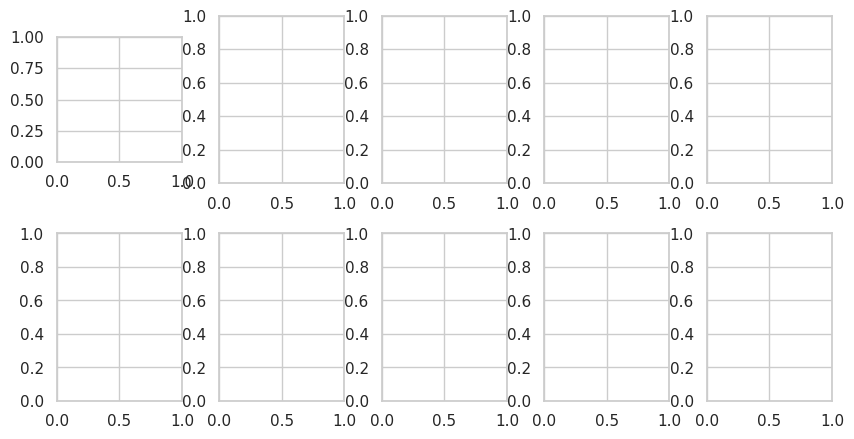

In [11]:
visualize_classes(train_loader, index_to_label)

In [11]:
dataset_managers = {
    'valid': valid_loader,
    'train': train_loader,
    'test': test_loader
}

print(f"Train set batches: {len(train_loader)}")
print(f"Validation set batches: {len(valid_loader)}")
print(f"Test set examples: {len(test_dataset)}")

Train set batches: 591
Validation set batches: 507
Test set examples: 4050


## Labels distribution

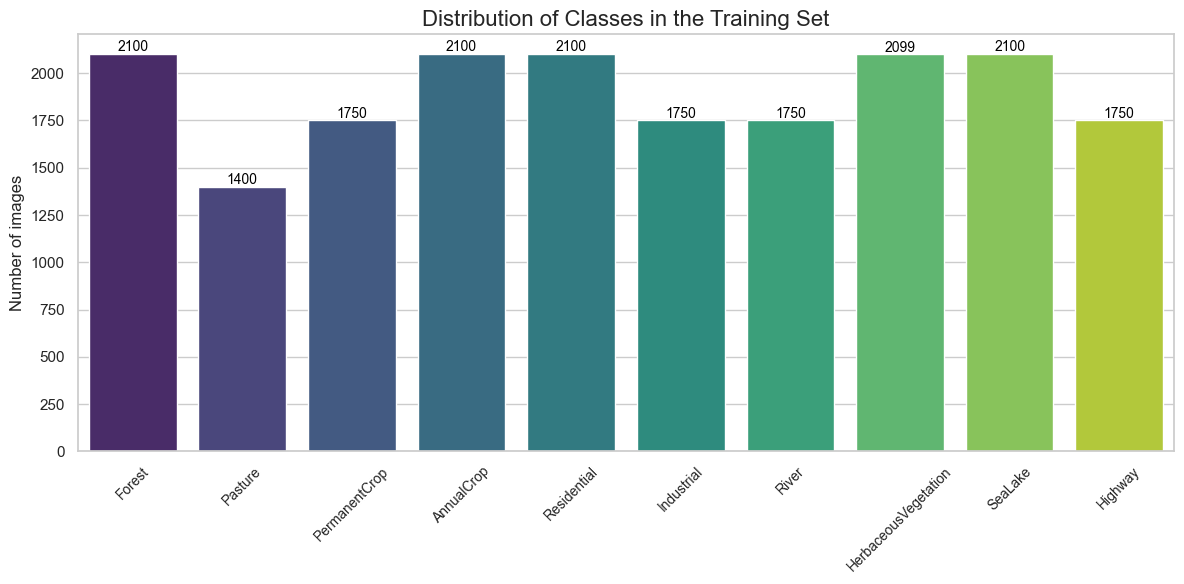

In [12]:
# Make sure to use the .data attribute from your updated EurosatDataset class
labels = train_dataset.data['Label'].values

# Convert numerical labels to string names
label_names = [index_to_label[label] for label in labels]

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.countplot(x=label_names, hue=label_names, palette="viridis", legend=False)

plt.ylabel('Number of images', fontsize=12)
plt.title('Distribution of Classes in the Training Set', fontsize=16)
plt.xticks(rotation=45, fontsize=10)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Model

In [ ]:
# Use un-pretrained model
model = vit_l_32()

# Replace the model head with the number of classes
num_classes = 10
model.heads.head = nn.Linear(1024, num_classes) 
model.to(DEVICE)

# # 使用更小的 vit_b_32 (基础版) 模型，而不是 vit_l_32 (大型版)
# model = vit_b_32()

# # Replace the model head with the number of classes
# num_classes = 10
# # 注意：基础版(Base)的 head 输入维度是 768，不是大型版(Large)的 1024
# model.heads.head = nn.Linear(768, num_classes) 
# model.to(DEVICE)

#add by wky for fusion
# 使用 vit_b_32 (基础版) 模型
# 可以选择加载预训练权重，这样只有第一层需要从头学
from torchvision.models import vit_b_32, ViT_B_32_Weights
model = vit_b_32(weights=ViT_B_32_Weights.DEFAULT)

# [核心修改] 替换第一个卷积层以接受6通道输入
# 原始层: Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
original_conv = model.conv_proj
model.conv_proj = nn.Conv2d(
    in_channels=6, 
    out_channels=original_conv.out_channels,  # 输出通道数保持不变 (768)
    kernel_size=original_conv.kernel_size,   # 核尺寸保持不变
    stride=original_conv.stride             # 步长保持不变
)

# 同样替换最终的分类头
num_classes = 10
model.heads.head = nn.Linear(768, num_classes) 
model.to(DEVICE)

# 打印模型，确认修改成功
print("模型结构已修改为接受6通道输入:")
print(model.conv_proj)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

# Training model from Scratch

In [14]:
# project_name = "EuroSAT"
# model_name = "ViT32"
# models_path = "./models/" # 建议使用相对路径

#add by wky
project_name = "EuroSAT"
model_name = "ViT32-Base-Scratch" # 增加了 "-Base-Scratch" 以表明是基础版且从零开始
models_path = "./models/" # 保持相对路径

In [15]:
epochs = 200
lr = 0.0001
patience = 10

run = wandb.init(
    project=project_name,
    name=model_name,
    notes="ViT32 from scratch",
    config={
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": train_batch,
        "patience": patience
    })

loss_i, loss_val_i = train_model(model=model, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience, device=DEVICE,
                                 model_name=model_name)

Starting training with early stopping patience of 10
Each epoch has 591 steps.

Epoch: 1...


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 2.00 GiB of which 0 bytes is free. Of the allocated memory 1.56 GiB is allocated by PyTorch, and 146.71 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Save model

In [ ]:
os.makedirs(models_path, exist_ok=True)
model_save_path = os.path.join(models_path, model_name + ".pth")
print(f"Saving model to: {model_save_path}")
torch.save(obj=model.state_dict(), f=model_save_path)

In [ ]:
with open(f"{models_path}/loss_{model_name}.txt", "w") as file:
    file.write(f"loss_i: {loss_i}\n")
    file.write(f"loss_val_i: {loss_val_i}\n")

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

## (以下代码块保持不变，继续进行评估和后续训练)...

# Evaluate model

In [ ]:
# Call this function before evaluating your model to remove any wandb hook
#remove_wandb_hooks(model)

## Load trained model

In [ ]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + f"{model_name}.pth"
print(f"Loading model {model_save_path}")
model.load_state_dict(torch.load(f = model_save_path))

Loading model C:/Users/jrtervens/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models/ViT32.pth


<All keys matched successfully>

In [ ]:
evaluate_test_set(model, test_loader, DEVICE, index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.902     0.917     0.909       300
              Forest      0.977     0.990     0.983       300
HerbaceousVegetation      0.897     0.897     0.897       300
             Highway      0.888     0.796     0.840       250
          Industrial      0.920     0.964     0.941       250
             Pasture      0.923     0.835     0.877       200
       PermanentCrop      0.828     0.888     0.857       250
         Residential      0.948     0.980     0.964       300
               River      0.875     0.900     0.888       250
             SeaLake      0.997     0.960     0.978       300

            accuracy                          0.917      2700
           macro avg      0.915     0.913     0.913      2700
        weighted avg      0.918     0.917     0.917      2700



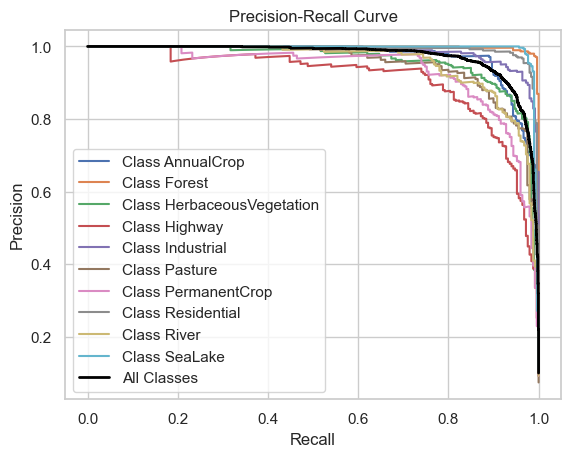

In [ ]:
precision_recall_analysis(model, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [ ]:
wandb.finish()

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▆▅▅▄▄▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▁▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▄▆▆▇▇▇▇▆▆▆▇▇▇▇▇▇▇▇▇██▇██▇███████▇█████
val_loss,█▅▅▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▂▁▁▂▁▁▁▂▂▁▁▂▂▂▂▁▂
epoch,62
step,37222
train_loss,0.05565
val_accuracy,0.90981
val_loss,0.33668


## Load the precision/recall curve and plot it

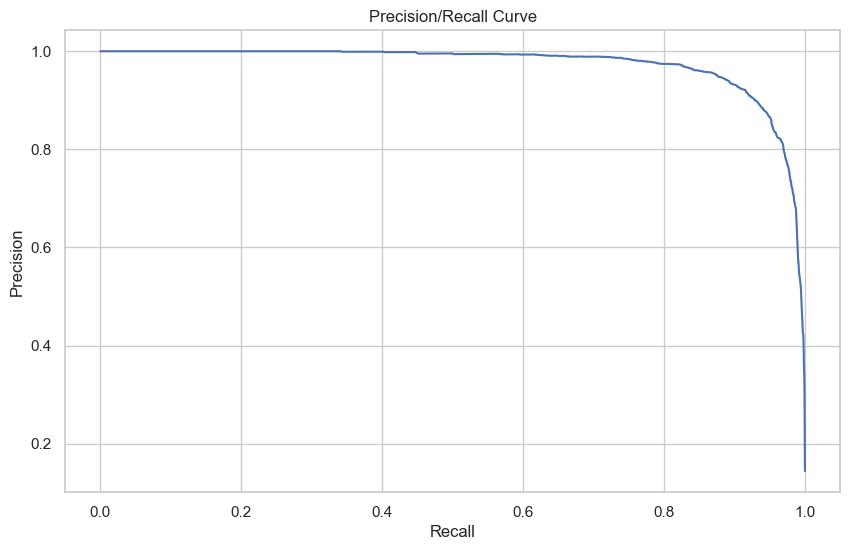

In [ ]:
filename = f"{model_name}_precision_recall_values.json"
file_path = os.path.join(models_path, filename)

with open(file_path, 'r') as file:
    precision_recall_data = json.load(file)
    
all_classes_data = precision_recall_data['All Classes']

# Extract precision and recall values
precisions = all_classes_data.get('precision', [])
recalls = all_classes_data.get('recall', [])

# Create a DataFrame for plotting
df = pd.DataFrame({
    'Precision': precisions,
    'Recall': recalls
})

# Plotting the precision/recall curve
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Recall', y='Precision')
plt.title('Precision/Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

## Clean-up

In [ ]:
import gc

del model
torch.cuda.empty_cache()
gc.collect()


26965

# Now train the model with pre-trained weights

In [ ]:
# Use pretrained model
model2 = vit_l_32(weights=ViT_L_32_Weights.IMAGENET1K_V1)

# Replace the model head with the number of classes
num_classes = 10
model2.heads.head = nn.Linear(1024, num_classes) 
model2.to(DEVICE)

VisionTransformer(
  (conv_proj): Conv2d(3, 1024, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=4096, out_features=1024, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
       

## Train with pre-trained weights

In [ ]:
model_name = "ViT32-Pretrained"

In [ ]:
epochs = 200
lr = 0.0001
patience = 10

run = wandb.init(
    # Set the project where this run will be logged
    project=project_name,
    name=model_name,
    notes="ViT32 pre-trained on ImageNet",
    # Track hyperparameters and run metadata
    config={
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": train_batch,
        "patience": patience
    })

loss_i, loss_val_i = train_model(model=model2, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience, device=DEVICE)

Starting training with early stopping patience of 10
Each epoch has 591 steps.

Epoch: 1...
Step: 21/591 Loss: 0.9762567549943924
Step: 41/591 Loss: 0.3474425382912159
Step: 61/591 Loss: 0.2393144192174077
Step: 81/591 Loss: 0.2194447247311473
Step: 101/591 Loss: 0.19572300724685193
Step: 121/591 Loss: 0.19638067223131656
Step: 141/591 Loss: 0.2215060146525502
Step: 161/591 Loss: 0.1577697589993477
Step: 181/591 Loss: 0.17699187006801367
Step: 201/591 Loss: 0.21709834672510625
Step: 221/591 Loss: 0.19292889554053544
Step: 241/591 Loss: 0.1846088904887438
Step: 261/591 Loss: 0.1588658457621932
Step: 281/591 Loss: 0.154608535207808
Step: 301/591 Loss: 0.2223818906582892
Step: 321/591 Loss: 0.16205594949424268
Step: 341/591 Loss: 0.18376472778618336
Step: 361/591 Loss: 0.25374312568455937
Step: 381/591 Loss: 0.12126316949725151
Step: 401/591 Loss: 0.09427432278171181
Step: 421/591 Loss: 0.11808200776576996
Step: 441/591 Loss: 0.11752560497261584
Step: 461/591 Loss: 0.13548197988420724
Ste

Step: 381/591 Loss: 0.06314802822598722
Step: 401/591 Loss: 0.022614044940564782
Step: 421/591 Loss: 0.009706411793013103
Step: 441/591 Loss: 0.017103840297204444
Step: 461/591 Loss: 0.0156237373535987
Step: 481/591 Loss: 0.027823773967975286
Step: 501/591 Loss: 0.023479407865670508
Step: 521/591 Loss: 0.021795087773352862
Step: 541/591 Loss: 0.036768975801533085
Step: 561/591 Loss: 0.027116884480346926
Step: 581/591 Loss: 0.026643655583029613
Validation Loss: 0.1362 Accuracy: 0.9630
Epoch duration: 270.25s

Epoch: 8...
Step: 21/591 Loss: 0.04397814597468823
Step: 41/591 Loss: 0.035226629523094743
Step: 61/591 Loss: 0.0837901015765965
Step: 81/591 Loss: 0.041262540477328004
Step: 101/591 Loss: 0.041712001420091835
Step: 121/591 Loss: 0.06299564055516385
Step: 141/591 Loss: 0.04550359596032649
Step: 161/591 Loss: 0.041702642582822594
Step: 181/591 Loss: 0.0663897201535292
Step: 201/591 Loss: 0.05688467861618847
Step: 221/591 Loss: 0.05045697421301156
Step: 241/591 Loss: 0.03054690691642

Step: 121/591 Loss: 0.035699009656673296
Step: 141/591 Loss: 0.025128578828298487
Step: 161/591 Loss: 0.008043318302952684
Step: 181/591 Loss: 0.02066217040846823
Step: 201/591 Loss: 0.021346937169437297
Step: 221/591 Loss: 0.033459757216041906
Step: 241/591 Loss: 0.009182683131075463
Step: 261/591 Loss: 0.013693328283261507
Step: 281/591 Loss: 0.03205636860366212
Step: 301/591 Loss: 0.027396816009422766
Step: 321/591 Loss: 0.02420768343145028
Step: 341/591 Loss: 0.009169277887849603
Step: 361/591 Loss: 0.009521506473538466
Step: 381/591 Loss: 0.0095133644528687
Step: 401/591 Loss: 0.028598169360338942
Step: 421/591 Loss: 0.010147169450647198
Step: 441/591 Loss: 0.021167716677882708
Step: 461/591 Loss: 0.02263932565692812
Step: 481/591 Loss: 0.01944013585016364
Step: 501/591 Loss: 0.01804604957869742
Step: 521/591 Loss: 0.04198246706509963
Step: 541/591 Loss: 0.017946365231182426
Step: 561/591 Loss: 0.013904356834245846
Step: 581/591 Loss: 0.02614851058460772
Validation Loss: 0.1410 Ac

## Save model

In [ ]:
# Create models directory
os.makedirs(models_path, exist_ok=True)

# 2. Create model save path
model_save_path = os.path.join(models_path, model_name + ".pth")

# 3. Save the model state dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model2.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=model_save_path)

Saving model to: C:/Users/jrtervens/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models\ViT32-Pretrained.pth


In [ ]:
# Save the loss data in a file
with open(f"{models_path}/loss_{model_name}.txt", "w") as archivo:
    archivo.write(f"loss_i: {loss_i}\n")
    archivo.write(f"loss_val_i: {loss_val_i}\n")

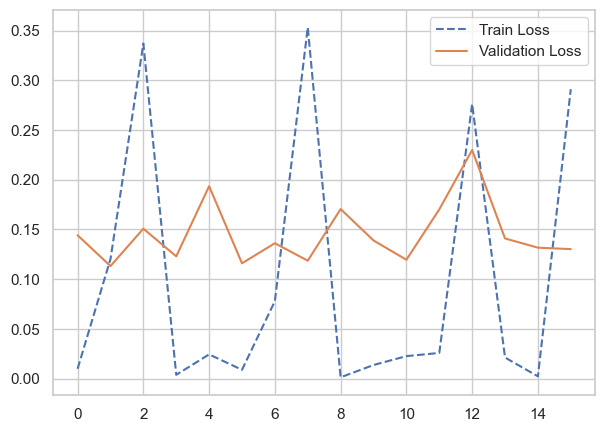

In [ ]:
plt.figure(figsize=(7,5))
# Use a dashed line for the training loss, and add markers
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)

# Use a solid line for the validation loss
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

# Evaluate model

In [ ]:
# Call this function before evaluating your model to remove any wandb hook
#remove_wandb_hooks(model)

## Load trained model

In [ ]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + f"{model_name}.pth"
print(f"Loading model {model_save_path}")
model2.load_state_dict(torch.load(f = model_save_path))

Loading model C:/Users/jrtervens/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models/ViT32-Pretrained.pth


<All keys matched successfully>

In [ ]:
evaluate_test_set(model2, test_loader, DEVICE, index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.967     0.987     0.977       300
              Forest      0.997     0.987     0.992       300
HerbaceousVegetation      0.930     0.970     0.949       300
             Highway      0.950     0.988     0.969       250
          Industrial      0.965     0.996     0.980       250
             Pasture      0.990     0.945     0.967       200
       PermanentCrop      0.950     0.912     0.931       250
         Residential      1.000     0.983     0.992       300
               River      0.976     0.960     0.968       250
             SeaLake      0.997     0.977     0.987       300

            accuracy                          0.972      2700
           macro avg      0.972     0.970     0.971      2700
        weighted avg      0.972     0.972     0.972      2700



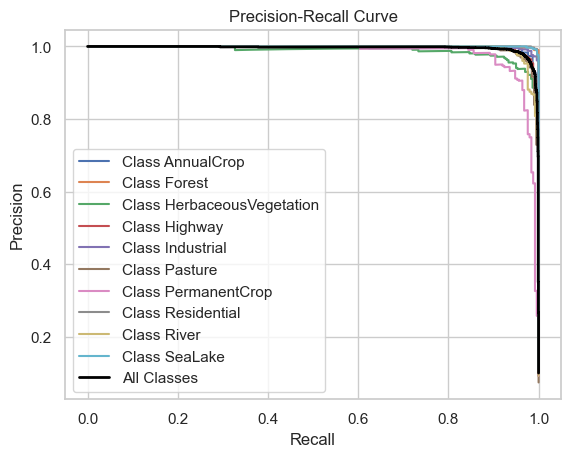

In [ ]:
precision_recall_analysis(model2, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [ ]:
wandb.finish()

epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▇▅▄▃▂▄▄▃▂▂▂▃▂▂▂▂▂▁▂▂▂▂▂▂▁▂▁▂▂▂▁▂▂▁▂▂▁▂▁
val_accuracy,▄▇▅█▁█▇█▅▇▇▅▁▇▇█
val_loss,▃▁▃▂▆▁▂▁▄▃▁▄█▃▂▂
epoch,15
step,9445
train_loss,0.00682
val_accuracy,0.965
val_loss,0.13027


In [ ]:
del model2
torch.cuda.empty_cache()
gc.collect()

18